In [322]:
from ESM_ACDC_Forcing import year_sum, the_model

import matplotlib.pyplot as plt
import numpy as np
import importlib
from tqdm import tqdm
import cmocean as cm
import scipy as sp

In [ ]:
import sys, importlib
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model


# test plot for rate constants

ds = the_model(nyear = 1e2, F_ext = lambda t: 10,g_V = 0.005)
Ocean_Flux = year_sum(ds.F_AS.values)/(1e12)
Land_Flux = year_sum(ds.F_LAND.values)/(4e12)


plt.figure(figsize=(13,8))
plt.subplot(3,1,1)
plt.plot(ds.time,ds.T_A,'k')
plt.plot(ds.time,ds.T_O.isel(ocean_depth=0),'C0')
plt.plot(ds.time,ds.T_O.isel(ocean_depth=-1),'C0--')
plt.ylabel('Temperature [˚C]')
#plt.ylim(0,10)

plt.subplot(3,1,2)
plt.plot(ds.time,ds.c_A,'k')
#plt.plot(ds.time_pco2,ds.pco2,'C0')
plt.ylabel('CO2 concentration ppmv')
# plt.ylim(280,1300)
#plt.plot(ds.time,ds.W_X)
#plt.ylabel('Soil Water [-]')
#plt.xlim(0,500)
plt.subplot(3,1,3)
plt.plot(ds.time,ds.F_LAND/(4e12))
#plt.plot(Flux_time,Ocean_Flux)
#plt.plot(ds.time,ds.DIC.isel(ocean_depth=0),'C0')
#plt.plot(ds.time,ds.DIC.isel(ocean_depth=-1),'C0--')
#plt.ylabel('DIC [umol/kg]')
plt.ylabel('Flux [PgC]')
#plt.ylim(2100,2200)
plt.xlabel('Time [Years]')
plt.show()

In [ ]:
import sys, importlib
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model

F_values = np.linspace(-20,20,30)
T_values = np.zeros_like(F_values)
C_values = np.zeros_like(F_values)
F_rad_values = np.zeros_like(F_values)

for i in tqdm(range(len(F_values))):
    F = F_values[i]
    F_ = lambda t: F
    ds = the_model(nyear = 5e3, F_ext = F_)

    T_values[i] = ds.T_A.values[-1]
    C_values[i] = ds.c_A.values[-1]
    F_rad_values[i] = ds.F_rad.values[-1]


In [ ]:
plt.figure(figsize=(10,6))

p=plt.scatter(T_values,C_values,c=F_values,cmap = cm.cm.balance)
plt.colorbar(p, label='External Radiative Forcing [W/m^2]')
plt.xlabel('Temperature perturbation [˚C]')
plt.ylabel('CO2 concentration [ppmv]')
plt.grid()

In [ ]:
plt.figure(figsize=(10,6))

p=plt.scatter(T_values,C_values,c=F_values,cmap = cm.cm.balance)
plt.gca().set_yscale('log')
plt.colorbar(p, label='External Radiative Forcing [W/m^2]')
plt.xlabel('Temperature perturbation [˚C]')
plt.ylabel('CO2 concentration [ppmv]')
plt.grid()

In [ ]:
plt.figure(figsize=(10,5))
plt.gca().set_aspect('equal', adjustable='box')
F_values_filled = np.linspace(-20,20,100)

p=plt.scatter(F_values,F_rad_values)
plt.plot(F_values_filled,F_values_filled,linestyle = '--',color = 'gray',label = '1:1 line')
plt.xlim([-30,30])
plt.ylim([-30,30])



plt.xlabel('External Radiative Forcing [W/m^2]')
plt.ylabel('Total radiative forcing [W/m^2]')
plt.grid()

In [ ]:
m,b,r,pval,_, = sp.stats.linregress(F_values,F_rad_values - F_values)

In [ ]:
plt.figure(figsize=(10,5))

p=plt.scatter(F_values,F_rad_values - F_values)

plt.xlabel('External Radiative Forcing [W/m^2]')
plt.ylabel('CO2 radiative forcing [W/m^2]')
plt.plot(F_values_filled,m*F_values_filled + b,linestyle = '-',color = 'C0',label = f'Linear fit: slope = {m:.2f}, intercept = {b:.2f}, r^2 = {r**2:.3f}')
plt.legend()
plt.grid()

In [304]:
import sys, importlib, itertools
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model

# now to test with varying stomatal conductance
g_V_values = np.linspace(0.0,0.02,22)
F_values = np.linspace(-10,10,21)

g_V_values_, F_V_values_ = np.meshgrid(g_V_values,F_values)

T_values = np.zeros_like(g_V_values_)
C_values = np.zeros_like(g_V_values_)
F_rad_values = np.zeros_like(g_V_values_)

for i, j in tqdm(itertools.product(range(len(F_values)), range(len(g_V_values))), total=len(F_values)*len(g_V_values)):
    F = F_values[i]
    F_ = lambda t: F
    g_V = g_V_values[j]
    ds = the_model(nyear = 10e3, F_ext = F_,g_V = g_V)

    T_values[i,j] = ds.T_A.values[-1]
    C_values[i,j] = ds.c_A.values[-1]
    F_rad_values[i,j] = ds.F_rad.values[-1]


  0%|          | 0/462 [00:00<?, ?it/s]

100%|██████████| 462/462 [3:36:14<00:00, 28.08s/it]    


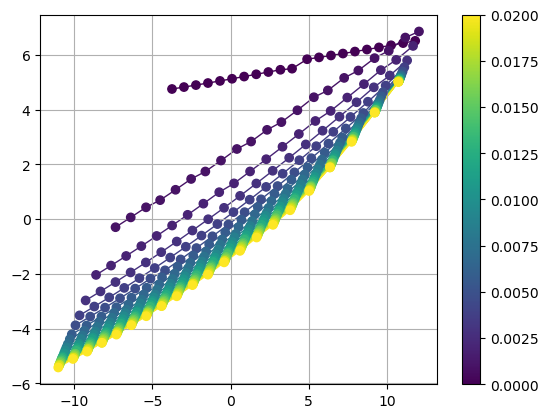

In [305]:
F_co2 = F_rad_values - F_V_values_
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(g_V_values_.min(), g_V_values_.max())
for j in range(len(g_V_values)):
    plt.plot(T_values[:,j], F_co2[:,j], color=cmap(norm(g_V_values[j])), linewidth=1, zorder=1)

pl = plt.scatter(T_values,F_co2, c = g_V_values_, cmap = 'viridis', zorder=2)
plt.grid()
plt.colorbar(pl)

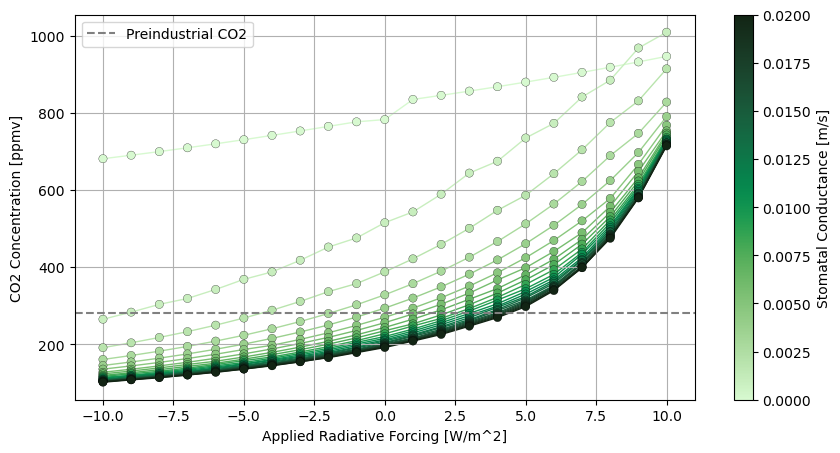

In [306]:
plt.figure(figsize=(10,5))

cmap = cm.cm.algae
norm = plt.Normalize(g_V_values_.min(), g_V_values_.max())
for j in range(len(g_V_values)):
    plt.plot(F_V_values_[:,j], C_values[:,j], color=cmap(norm(g_V_values[j])), linewidth=1, zorder=1)

pl = plt.scatter(F_V_values_,C_values, c = g_V_values_, cmap = cm.cm.algae, edgecolors='black', linewidth=0.2, zorder=2)
plt.grid()
plt.colorbar(pl,label = 'Stomatal Conductance [m/s]')
plt.ylabel('CO2 Concentration [ppmv]')
plt.xlabel('Applied Radiative Forcing [W/m^2]')
plt.axhline(y=280, color='gray', linestyle='--', label='Preindustrial CO2')
plt.legend()


(-12.013298009150319, 13.040312665661322)

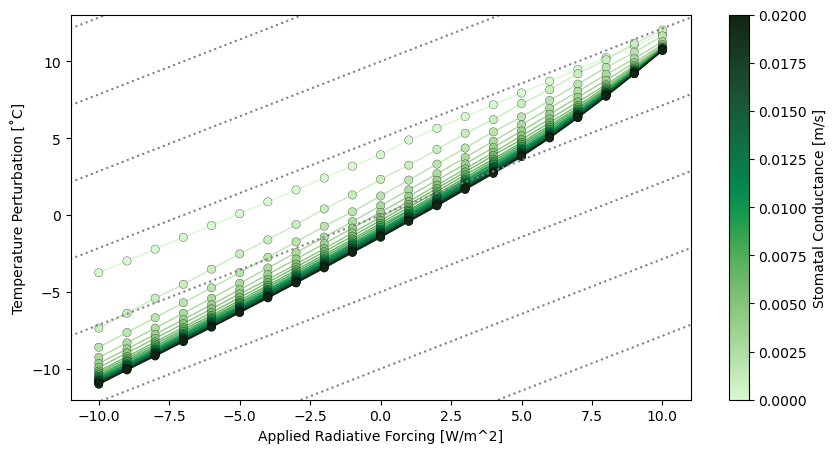

In [307]:
plt.figure(figsize=(10,5))

cmap = cm.cm.algae
norm = plt.Normalize(g_V_values_.min(), g_V_values_.max())
for j in range(len(g_V_values)):
    plt.plot( F_V_values_[:,j],T_values[:,j], color=cmap(norm(g_V_values[j])), linewidth=1, zorder=1)

pl = plt.scatter(F_V_values_,T_values, c = g_V_values_, cmap = cm.cm.algae, edgecolors='black', linewidth=0.2, zorder=2)

plt.colorbar(pl,label = 'Stomatal Conductance [m/s]')
plt.ylabel('Temperature Perturbation [˚C]')
plt.xlabel('Applied Radiative Forcing [W/m^2]')

lam = 1/abs(1.4)  # Climate feedback parameter [W/m^2/K], from ESM_ACDC_Forcing.py
x_line = np.array([T_values.min(), T_values.max()])
for i in range(-10,10):
    plt.plot(x_line, lam*x_line + i*5, linestyle=':', color='gray')

plt.xlim([np.min(F_V_values_) - 1, np.max(F_V_values_) + 1])
plt.ylim([np.min(T_values) - 1, np.max(T_values) + 1])

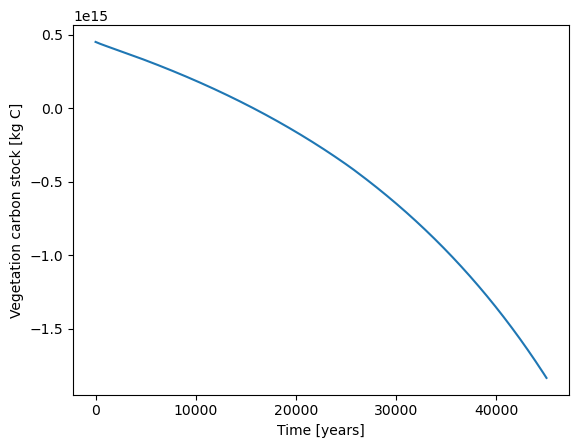

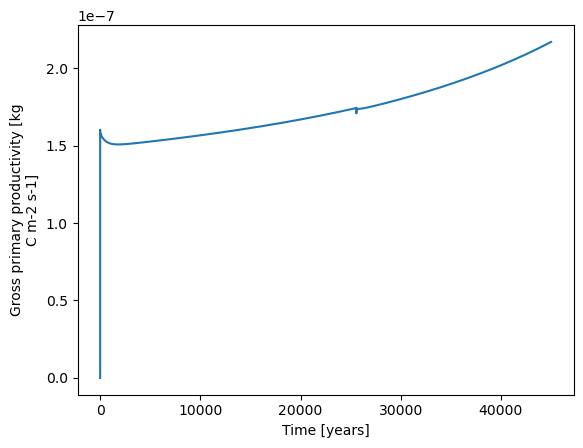

In [331]:
import sys, importlib, itertools
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model

ds = the_model(nyear = 45e3, F_ext = lambda t: 1)
ds.C_VEG.plot()
plt.show()
ds.GPP.plot()
plt.show()